In [1]:
%pip install -U -q numpy pandas wfdb matplotlib notebook scikit-learn PyWavelets plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


import wfdb
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.linear_model import LinearRegression

import funkcje
from processor import Signal, ICP_ABP_Processor

#MAJA I MANIA DETEKCJA EVENTÓW

In [1]:
import os
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Sekcja wczytwania


Uruchamiam szybkie przetwarzanie wektorowe Pandas...

 ZAKOŃCZONO ANALIZĘ
  * Czas trwania sygnału: 244797.0 s, (4079.95 m) (68.00 h)
  * Liczba wykrytych zdarzeń (eventów): 20
  * Liczba zaakceptowanych segmentów klinicznych: 16



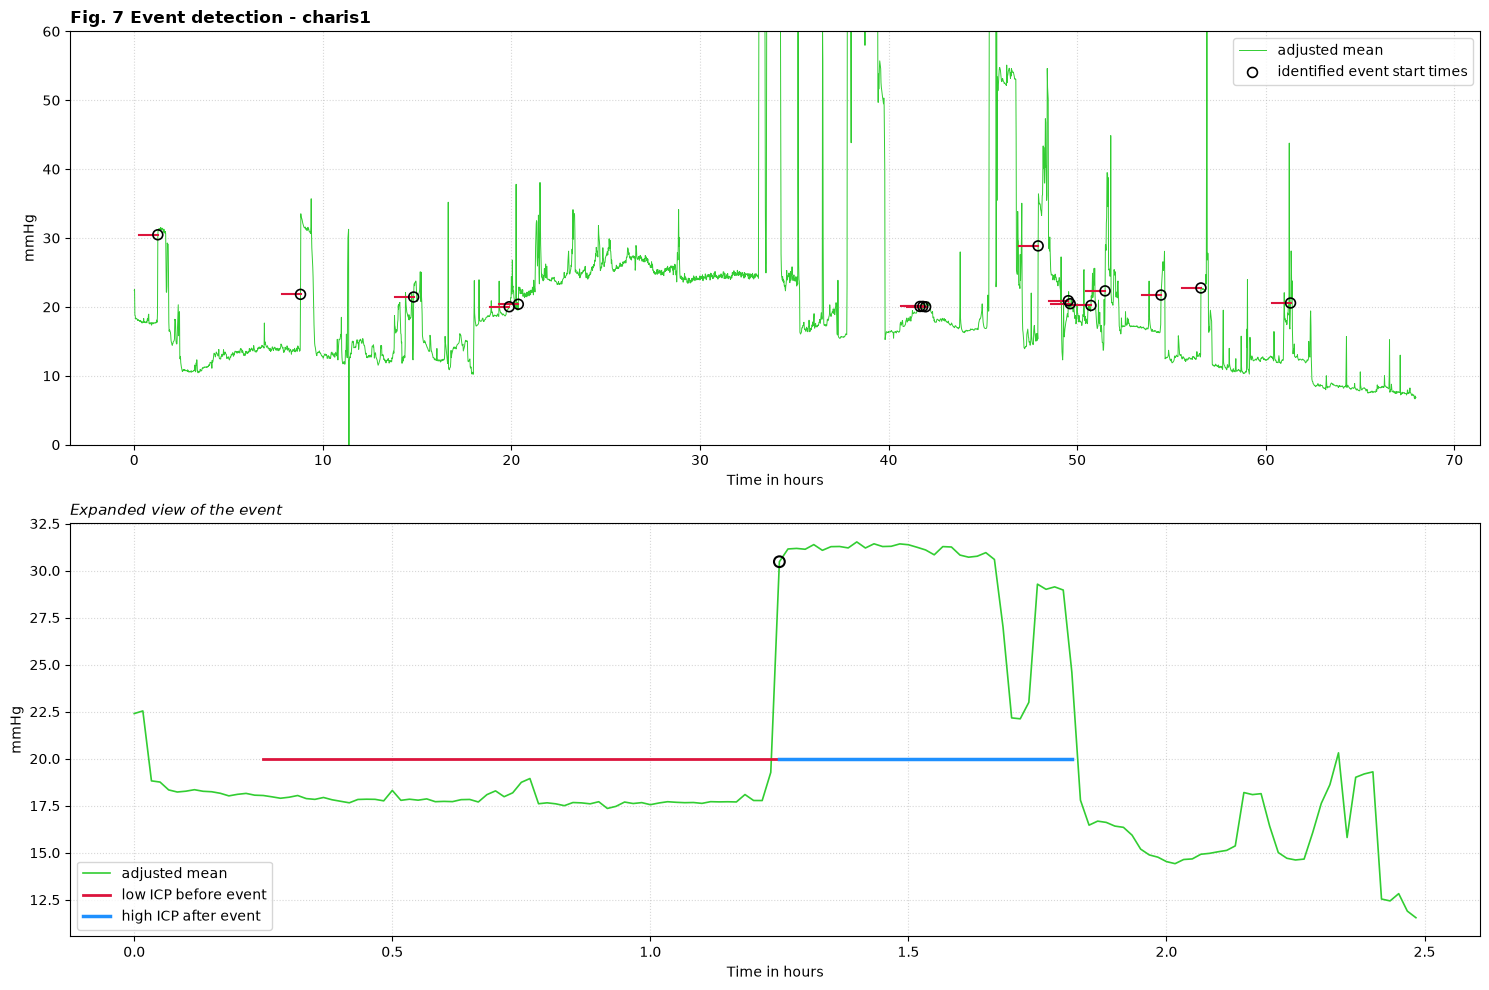

In [ ]:
import os
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. KLASA PRZETWARZAJĄCA ZGODNIE ZE SCHEMATEM BLOKOWYM ---
class ICP_ABP_Processor:
    def __init__(self, channel_icp, channel_abp, sampling_freq, record_name):
        self.channel_icp = channel_icp
        self.channel_abp = channel_abp
        self.fs = sampling_freq
        self.final_segments = []
        self.df = None
        self.total_events_count = 0 
        self.record_name = record_name

    def process_all(self):
        print("Uruchamiam szybkie przetwarzanie wektorowe Pandas...")
        
        # Etapy 1-3: Podział na minuty i obliczenie wartości średnich (MICP i MABP)
        samples_per_min = int(self.fs * 60)
        full_mins = len(self.channel_icp) // samples_per_min
        
        icp_matrix = self.channel_icp[:full_mins * samples_per_min].reshape(full_mins, samples_per_min)
        abp_matrix = self.channel_abp[:full_mins * samples_per_min].reshape(full_mins, samples_per_min)
        
        self.df = pd.DataFrame({
            'MICP': icp_matrix.mean(axis=1),
            'MABP': abp_matrix.mean(axis=1)
        })
        
        # Etap 4: Detekcja i usunięcie zakłóceń (>50 mmHg)
        self.df['is_valid'] = self.df['MICP'] <= 50
        
        # Etap 5: Detekcja zdarzeń (>25 mmHg przez co najmniej 5 min)
        self.df['event_condition'] = self.df['is_valid'] & (self.df['MICP'] > 20)
        self.df['block_id'] = (~self.df['event_condition']).cumsum()
        
        event_blocks = self.df[self.df['event_condition']].groupby('block_id').size()
        valid_event_blocks = event_blocks[event_blocks >= 5].index
        
        self.total_events_count = len(valid_event_blocks)
        
        # Oznaczamy minuty, które wchodzą w skład poprawnych eventów (potrzebne do wykresu)
        self.df['is_event'] = self.df['event_condition'] & self.df['block_id'].isin(valid_event_blocks)
        
        # Etap 6: Podział na segmenty (1 h prawidłowego sygnału przed + zdarzenie)
        for block in valid_event_blocks:
            event_minutes = self.df[(self.df['block_id'] == block) & self.df['event_condition']].index
            event_start = event_minutes.min()
            event_end = event_minutes.max()
            
            # Musimy mieć przynajmniej 60 minut sygnału przed startem
            if event_start >= 60:
                pre_event_window = self.df.loc[event_start - 60 : event_start - 1, 'is_valid']
                # Jeśli cała godzina przed jest prawidłowa (czysta od zakłóceń)
                if pre_event_window.all():
                    self.final_segments.append({
                        'pre_event_start_min': event_start - 60,
                        'event_start_min': event_start,
                        'event_end_min': event_end,
                        'duration_min': (event_end - event_start) + 1
                    })
            with open(f'Events/DetectedEvents-{self.record_name}.txt','w') as f:
                for line in self.final_segments:
                    f.write(f'{line}\n')

        total_seconds = len(self.channel_icp) / self.fs
        print("\n" + "="*50)
        print(f" ZAKOŃCZONO ANALIZĘ")
        print("="*50)
        print(f"  * Czas trwania sygnału: {total_seconds:.1f} s, ({total_seconds/60:.2f} m) ({total_seconds/3600:.2f} h)")
        print(f"  * Liczba wykrytych zdarzeń (eventów): {self.total_events_count}")
        print(f"  * Liczba zaakceptowanych segmentów klinicznych: {len(self.final_segments)}")
        print("="*50 + "\n")


# =========================================================================
# 2. WCZYTYWANIE REKORDU (WFDB)
# =========================================================================
data_dir = 'charis-database-1.0.0'  
base_name = 'charis'
#record_name = 'charis1'             
for record_name in (
    base_name+1,
    base_name+2,
    base_name+3,
    base_name+4,
    base_name+10,
    base_name+11,
):

    os.makedirs(data_dir, exist_ok=True)
    local_path = os.path.join(data_dir, record_name)

    record = wfdb.rdrecord(local_path)
    signals = record.p_signal  
    fs = record.fs  

    channel_ABP = signals[:, 0]
    channel_ICP = signals[:, 2]

    # Uruchomienie obliczeń
    processor = ICP_ABP_Processor(channel_ICP, channel_ABP, sampling_freq=fs, record_name=record_name)
    processor.process_all()


# =========================================================================
# 3. GENEROWANIE WYKRESU W STYLU "FIG. 7 EVENT DETECTION"
# =========================================================================
# Tworzymy dwa wykresy jeden pod drugim (Główny oraz Przybliżenie)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Przeliczamy indeksy minutowe z ramki DataFrame na godziny dla osi X
time_hours = processor.df.index / 60

# --- WYKRES 1: CAŁOŚĆ (GÓRA) ---
ax1.plot(time_hours, processor.df['MICP'], color='limegreen', linewidth=0.7, label='adjusted mean')

# Naniesienie kółeczek i linii "quiet period" dla każdego segmentu klinicznego
for i, seg in enumerate(processor.final_segments):
    start_h = seg['event_start_min'] / 60
    pre_start_h = seg['pre_event_start_min'] / 60
    # Pobieramy wartość ICP w minucie startu, aby na tej wysokości narysować linię
    y_val = processor.df.loc[seg['event_start_min'], 'MICP']
    
    # Czerwona linia oznaczająca okres ciszy przed zdarzeniem (1 godzina)
    ax1.plot([pre_start_h, start_h], [y_val, y_val], color='crimson', linewidth=1.5, zorder=3)
    
    # Czarne kółeczko oznaczające dokładny początek zdarzenia
    # Używamy label tylko dla pierwszego elementu, żeby nie dublować legendy
    lbl = 'identified event start times' if i == 0 else ""
    ax1.scatter(start_h, y_val, facecolors='none', edgecolors='black', s=50, linewidth=1.2, zorder=4, label=lbl)

ax1.set_title(f'Fig. 7 Event detection - {record_name}', fontsize=12, fontweight='bold', loc='left')
ax1.set_xlabel('Time in hours')
ax1.set_ylabel('mmHg')
ax1.set_ylim(0, 60)
ax1.grid(True, linestyle=':', alpha=0.5)
ax1.legend(loc='upper right')


# --- WYKRES 2: EXPANDED VIEW (DÓŁ) ---
if len(processor.final_segments) > 0:
    # Do prezentacji przybliżenia wybieramy pierwszy spełniający warunki segment
    seg_zoom = processor.final_segments[0]
    
    # Określamy granice przybliżenia: 40 minut przed okresem ciszy i 40 minut po evencie
    pad_mins = 40
    zoom_start_min = max(0, seg_zoom['pre_event_start_min'] - pad_mins)
    zoom_end_min = min(len(processor.df) - 1, seg_zoom['event_end_min'] + pad_mins)
    
    # Wycinamy fragment danych do przybliżenia
    df_zoom = processor.df.loc[zoom_start_min:zoom_end_min]
    time_hours_zoom = df_zoom.index / 60
    
    # Rysujemy zieloną linię sygnału w przybliżeniu
    ax2.plot(time_hours_zoom, df_zoom['MICP'], color='limegreen', linewidth=1.2, label='adjusted mean')
    
    # Wyznaczamy współrzędne czasowe w godzinach dla linii statusu
    h_pre_start = seg_zoom['pre_event_start_min'] / 60
    h_event_start = seg_zoom['event_start_min'] / 60
    h_event_end = seg_zoom['event_end_min'] / 60
    
    # Czerwona pozioma linia: "low ICP before event" (okres ciszy) na wysokości 25 mmHg
    ax2.plot([h_pre_start, h_event_start], [20, 20], color='crimson', linewidth=2, label='low ICP before event')
    
    # Niebieska pozioma linia: "high ICP after event" (trwanie eventu) na wysokości 25 mmHg
    ax2.plot([h_event_start, h_event_end], [20, 20], color='dodgerblue', linewidth=2.5, label='high ICP after event')
    
    # Czarne kółeczko w punkcie startu na wykresie przybliżonym
    y_zoom_start = processor.df.loc[seg_zoom['event_start_min'], 'MICP']
    ax2.scatter(h_event_start, y_zoom_start, facecolors='none', edgecolors='black', s=60, linewidth=1.5, zorder=4)
    
    ax2.set_title(f'Expanded view of the event', fontsize=11, style='italic', loc='left')
    ax2.set_xlabel('Time in hours')
    ax2.set_ylabel('mmHg')
    ax2.grid(True, linestyle=':', alpha=0.5)
    ax2.legend(loc='lower left')
else:
    # Komunikat awaryjny, jeśli żaden event nie miał idealnej godziny czystego sygnału przed sobą
    ax2.text(0.5, 0.5, "Brak segmentów klinicznych spełniających\nkryterium 1h czystego sygnału przed eventem.", 
             ha='center', va='center', fontsize=12, color='gray')

plt.tight_layout()
plt.show()
